# PHẦN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) - CYBERSECURITY INTRUSION DETECTION

##  Định nghĩa vấn đề

### Mô tả
- phân tích dữ liệu lưu lượng mạng nhằm phát hiện các hành vi xâm nhập (intrusion detection).  
- dữ liệu đầu vào là file `cybersecurity_intrusion_data.csv`.  

### Mục tiêu
- khám phá cấu trúc và đặc điểm của dữ liệu.  
- trực quan hóa phân bố các biến số.  
- phân tích mối quan hệ giữa các đặc trưng.  
- xác định biến mục tiêu phục vụ mô hình học máy.  

In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)

# Cấu hình font chữ tiếng Việt cho matplotlib (nếu cần)
# plt.rcParams['font.sans-serif'] = 'Arial'  # Hoặc 'DejaVu Sans'

# Đọc dữ liệu đã được tiền xử lý từ file parquet
df = pd.read_parquet("../data_processed/cleaned_data.parquet")
print(f"Kích thước dữ liệu: {df.shape[0]} hàng, {df.shape[1]} cột")
print("Các cột hiện có:", list(df.columns))

Kích thước dữ liệu: 7571 hàng, 10 cột
Các cột hiện có: ['network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access', 'attack_detected']


### 1. TỔNG QUAN VỀ DỮ LIỆU (DATA OVERVIEW)


In [2]:
print("=== 1. TỔNG QUAN VỀ DỮ LIỆU ===")
print("\n1.1. Thông tin các cột và kiểu dữ liệu:")
df.info()

print("\n1.2. Thống kê mô tả cho biến số (numerical features):")
display(df.describe())

print("\n1.3. Thống kê mô tả cho biến phân loại (categorical features):")
categorical_cols = ['protocol_type', 'encryption_used', 'browser_type', 'unusual_time_access', 'attack_detected']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts())
        if col != 'attack_detected':
            print(f"Tỷ lệ (%) so với tổng:")
            print(df[col].value_counts(normalize=True).mul(100).round(2))

print("\n" + "="*80 + "\n")

=== 1. TỔNG QUAN VỀ DỮ LIỆU ===

1.1. Thông tin các cột và kiểu dữ liệu:
<class 'pandas.DataFrame'>
Index: 7571 entries, 0 to 9535
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   network_packet_size  7571 non-null   int64  
 1   protocol_type        7571 non-null   str    
 2   login_attempts       7571 non-null   int64  
 3   session_duration     7571 non-null   float64
 4   encryption_used      7571 non-null   str    
 5   ip_reputation_score  7571 non-null   float64
 6   failed_logins        7571 non-null   int64  
 7   browser_type         7571 non-null   str    
 8   unusual_time_access  7571 non-null   int64  
 9   attack_detected      7571 non-null   int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 739.3 KB

1.2. Thống kê mô tả cho biến số (numerical features):


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,7571.000000,7571.000000,7571.000000,7571.000000,7571.000000,7571.000000,7571.000000
mean,499.556598,4.031832,789.334671,0.330749,1.523313,0.150707,0.443006
std,198.458221,1.963112,789.993725,0.177953,1.036751,0.357786,0.496774
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,364.000000,3.000000,230.590993,0.190350,1.000000,0.000000,0.000000
50%,498.000000,4.000000,547.137302,0.313306,1.000000,0.000000,0.000000
75%,632.000000,5.000000,1101.216078,0.453525,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000



1.3. Thống kê mô tả cho biến phân loại (categorical features):

--- protocol_type ---
protocol_type
TCP     5235
UDP     1941
ICMP     395
Name: count, dtype: int64
Tỷ lệ (%) so với tổng:
protocol_type
TCP     69.15
UDP     25.64
ICMP     5.22
Name: proportion, dtype: float64

--- encryption_used ---
encryption_used
AES    4706
DES    2865
Name: count, dtype: int64
Tỷ lệ (%) so với tổng:
encryption_used
AES    62.16
DES    37.84
Name: proportion, dtype: float64

--- browser_type ---
browser_type
Chrome     4082
Firefox    1527
Edge       1183
Unknown     397
Safari      382
Name: count, dtype: int64
Tỷ lệ (%) so với tổng:
browser_type
Chrome     53.92
Firefox    20.17
Edge       15.63
Unknown     5.24
Safari      5.05
Name: proportion, dtype: float64

--- unusual_time_access ---
unusual_time_access
0    6430
1    1141
Name: count, dtype: int64
Tỷ lệ (%) so với tổng:
unusual_time_access
0    84.93
1    15.07
Name: proportion, dtype: float64

--- attack_detected ---
attack_detected
0   

### 2. KIỂM TRA GIÁ TRỊ BẤT THƯỜNG (OUTLIERS) VÀ PHÂN PHỐI


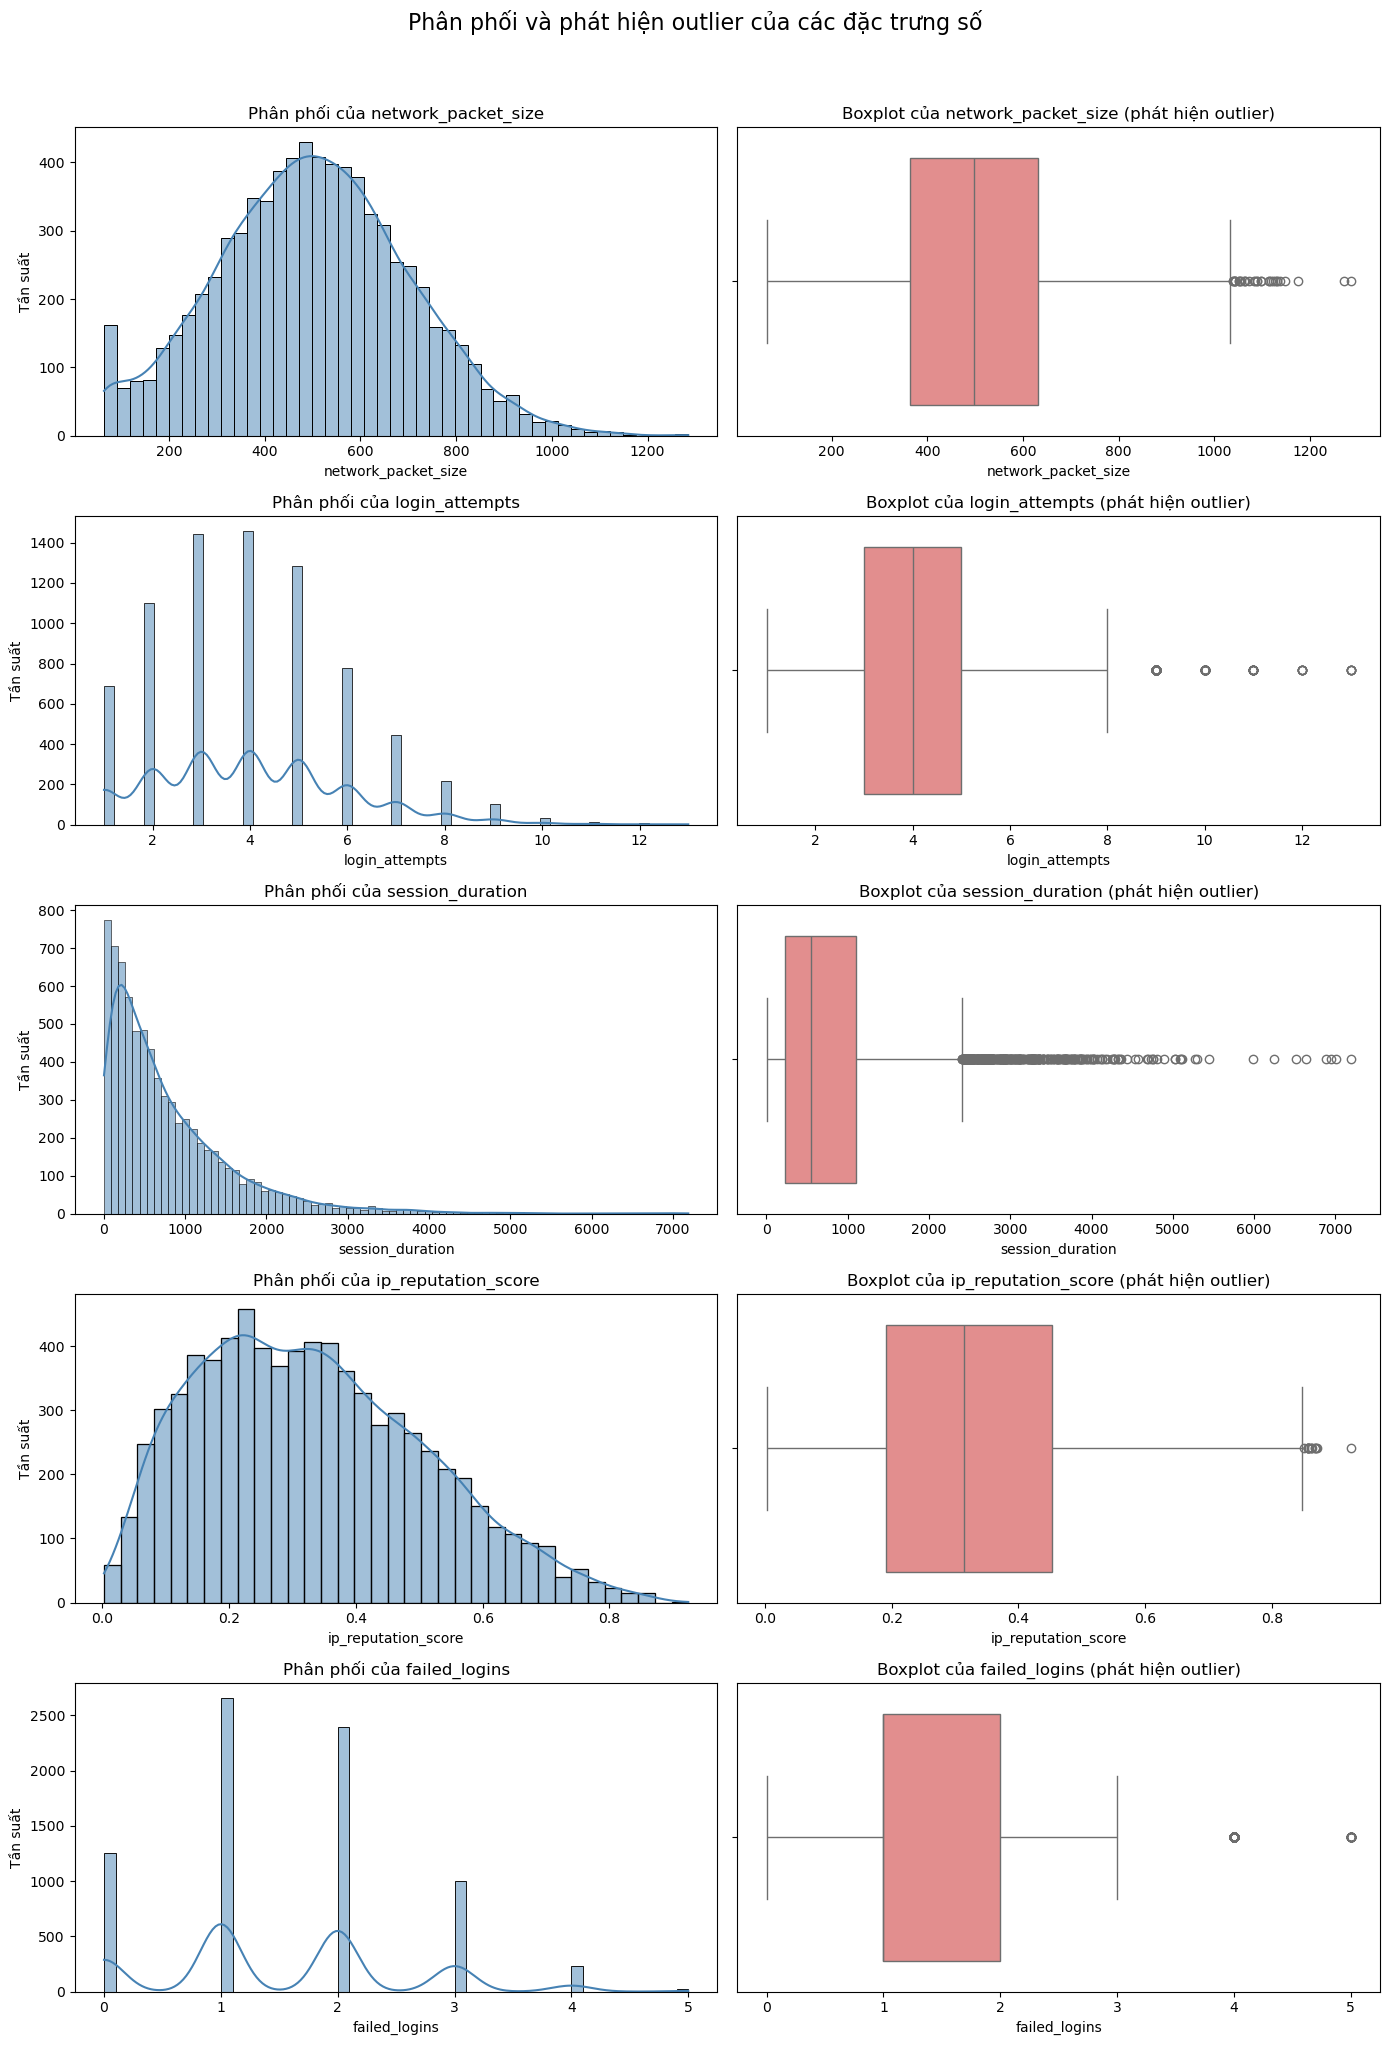


2.2. Phát hiện outlier bằng phương pháp IQR (Interquartile Range):

--- network_packet_size ---
  Q1 = 364.00, Q3 = 632.00, IQR = 268.00
  Giới hạn dưới: -38.00, Giới hạn trên: 1034.00
  Số lượng outlier: 32 (0.42%)

--- login_attempts ---
  Q1 = 3.00, Q3 = 5.00, IQR = 2.00
  Giới hạn dưới: 0.00, Giới hạn trên: 8.00
  Số lượng outlier: 162 (2.14%)

--- session_duration ---
  Q1 = 230.59, Q3 = 1101.22, IQR = 870.63
  Giới hạn dưới: -1075.35, Giới hạn trên: 2407.15
  Số lượng outlier: 344 (4.54%)

--- ip_reputation_score ---
  Q1 = 0.19, Q3 = 0.45, IQR = 0.26
  Giới hạn dưới: -0.20, Giới hạn trên: 0.85
  Số lượng outlier: 15 (0.20%)

--- failed_logins ---
  Q1 = 1.00, Q3 = 2.00, IQR = 1.00
  Giới hạn dưới: -0.50, Giới hạn trên: 3.50
  Số lượng outlier: 262 (3.46%)


In [3]:
# Xác định các cột số
numeric_cols = ['network_packet_size', 'login_attempts', 'session_duration', 
                'ip_reputation_score', 'failed_logins']

# 2.1. Biểu đồ phân phối (histogram) và boxplot cho từng cột số
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(14, 4*len(numeric_cols)))
fig.suptitle('Phân phối và phát hiện outlier của các đặc trưng số', fontsize=16, y=1.02)

for i, col in enumerate(numeric_cols):
    # Histogram với KDE
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'Phân phối của {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Tần suất')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot của {col} (phát hiện outlier)')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

# 2.2. Thống kê chi tiết về outlier (sử dụng IQR)
print("\n2.2. Phát hiện outlier bằng phương pháp IQR (Interquartile Range):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n--- {col} ---")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  Giới hạn dưới: {lower_bound:.2f}, Giới hạn trên: {upper_bound:.2f}")
    print(f"  Số lượng outlier: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

### 3. PHÂN TÍCH QUAN HỆ GIỮA CÁC BIẾN (FEATURE RELATIONSHIPS)


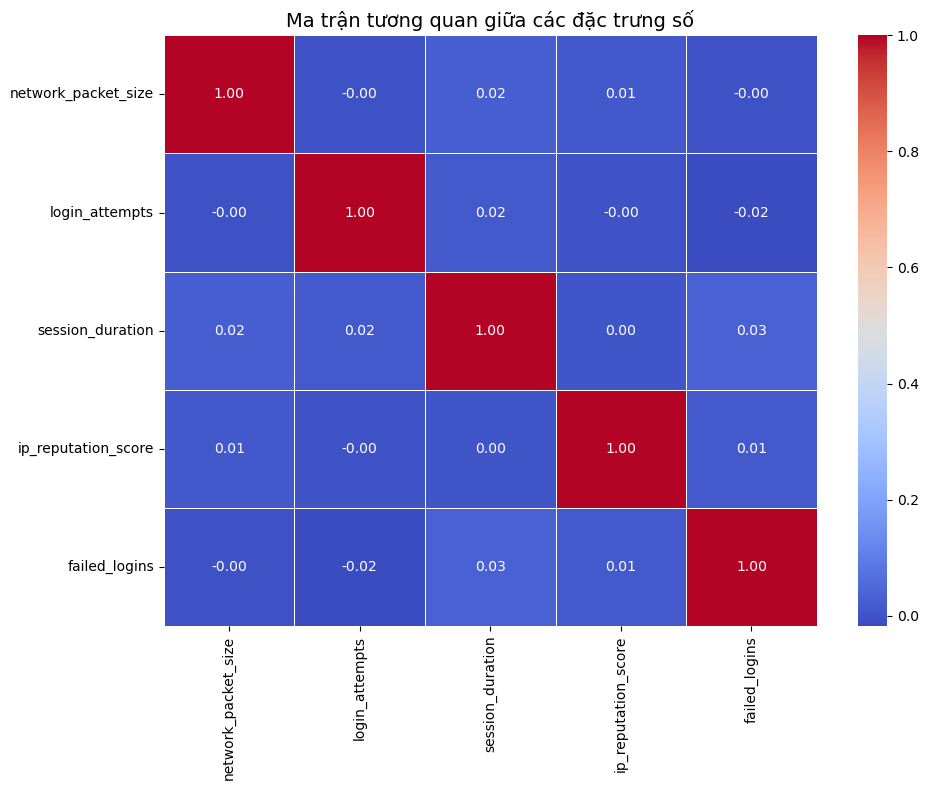


3.1. Các cặp đặc trưng có tương quan mạnh (> 0.5 hoặc < -0.5):

3.2. Tương quan giữa các đặc trưng số và biến mục tiêu 'attack_detected':
attack_detected        1.000000
failed_logins          0.367502
login_attempts         0.276770
ip_reputation_score    0.214994
session_duration       0.052671
network_packet_size   -0.007136
Name: attack_detected, dtype: float64


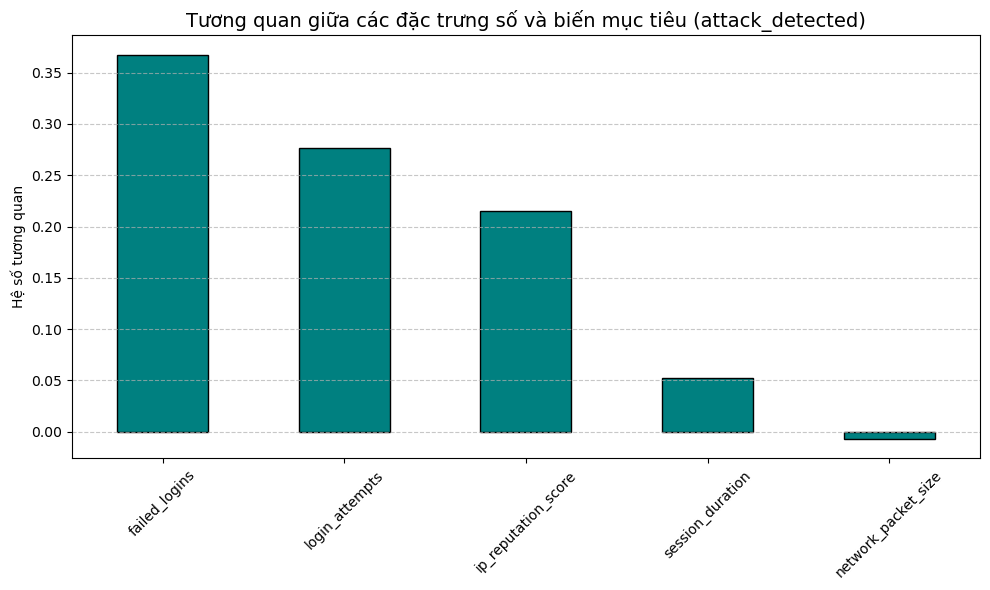

In [4]:

# 3.1. Ma trận tương quan (correlation matrix) cho biến số
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng số', fontsize=14)
plt.tight_layout()
plt.show()

# In ra các cặp tương quan cao (|r| > 0.5)
print("\n3.1. Các cặp đặc trưng có tương quan mạnh (> 0.5 hoặc < -0.5):")
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.5:
            print(f"  {numeric_cols[i]} và {numeric_cols[j]}: {corr:.2f}")

# 3.2. Phân tích tương quan giữa các biến số với biến mục tiêu 'attack_detected'
print("\n3.2. Tương quan giữa các đặc trưng số và biến mục tiêu 'attack_detected':")
target_corr = df[numeric_cols + ['attack_detected']].corr()['attack_detected'].sort_values(ascending=False)
print(target_corr)

# Vẽ barplot thể hiện tương quan với target
plt.figure(figsize=(10, 6))
target_corr.drop('attack_detected').plot(kind='bar', color='teal', edgecolor='black')
plt.title('Tương quan giữa các đặc trưng số và biến mục tiêu (attack_detected)', fontsize=14)
plt.ylabel('Hệ số tương quan')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 4. SO SÁNH GIỮA LỚP BÌNH THƯỜNG (0) VÀ LỚP TẤN CÔNG (1)


4.1. Thống kê mô tả các đặc trưng số theo từng lớp:

--- network_packet_size ---
                  count    mean     std   min    25%    50%    75%     max
attack_detected                                                           
0                4217.0  500.82  198.28  64.0  367.0  499.0  632.0  1285.0
1                3354.0  497.97  198.70  64.0  360.0  497.0  633.0  1270.0

--- login_attempts ---
                  count  mean   std  min  25%  50%  75%   max
attack_detected                                              
0                4217.0  3.55  1.51  1.0  2.0  4.0  5.0   6.0
1                3354.0  4.64  2.27  1.0  3.0  4.0  6.0  13.0

--- session_duration ---
                  count    mean     std  min     25%     50%      75%      max
attack_detected                                                               
0                4217.0  752.23  727.03  0.5  226.84  536.22  1052.36  7190.39
1                3354.0  835.99  860.51  0.5  234.50  557.94  1169.45  7005.65

---

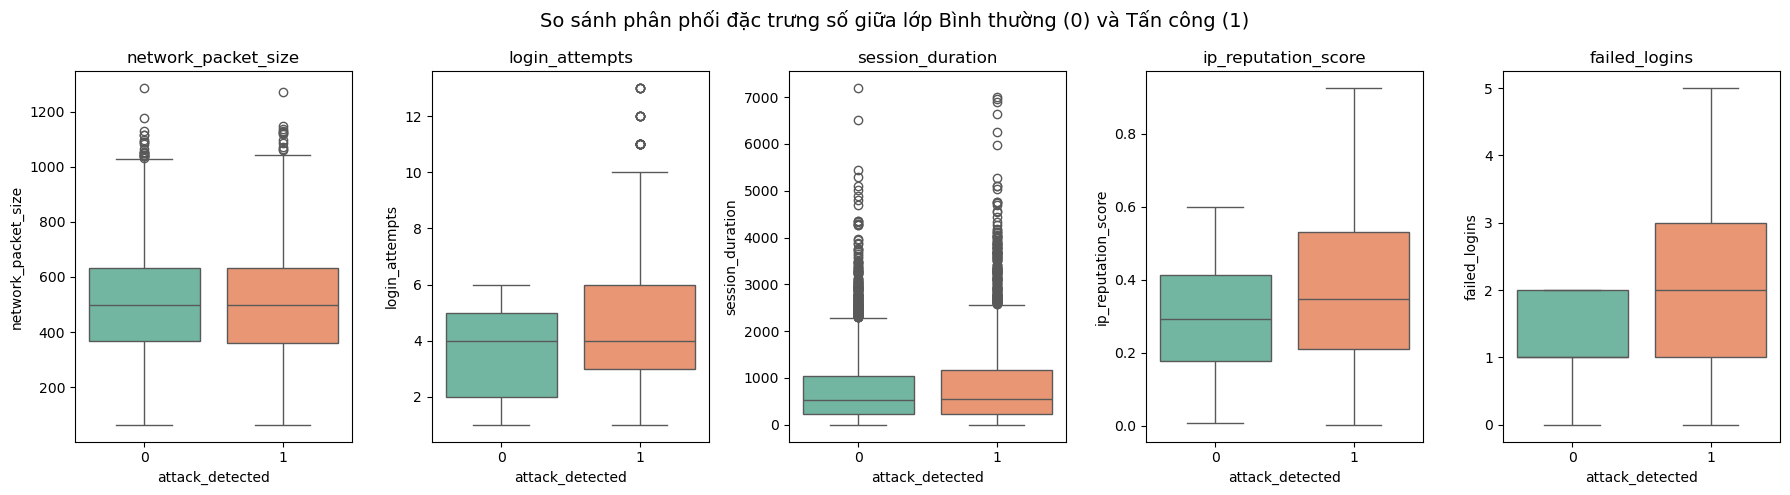

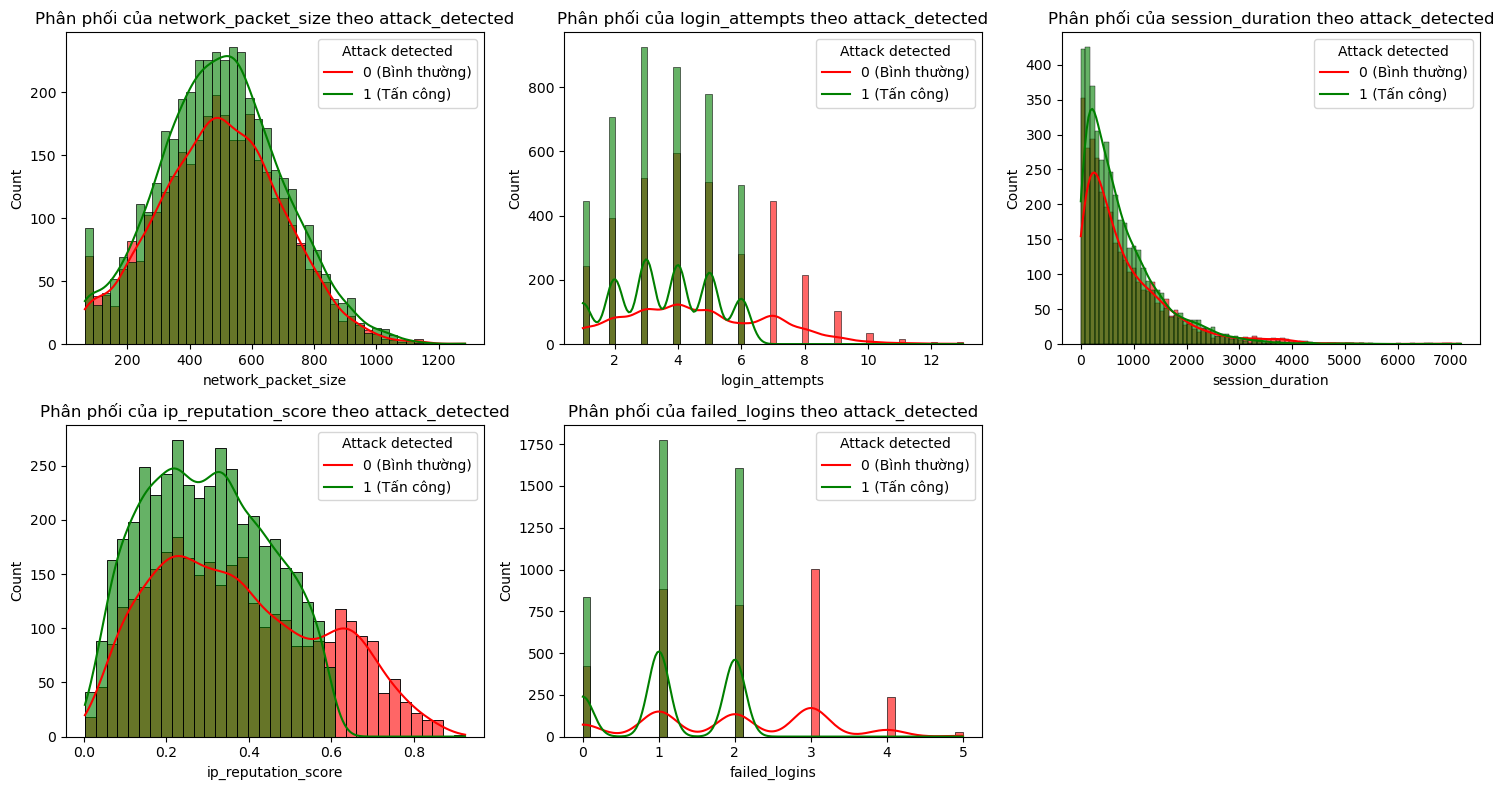

In [5]:

# 4.1. Thống kê mô tả theo từng lớp
print("\n4.1. Thống kê mô tả các đặc trưng số theo từng lớp:")
for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(df.groupby('attack_detected')[col].describe().round(2))

# 4.2. Biểu đồ boxplot so sánh phân phối giữa 2 lớp
fig, axes = plt.subplots(nrows=1, ncols=len(numeric_cols), figsize=(18, 5))
fig.suptitle('So sánh phân phối đặc trưng số giữa lớp Bình thường (0) và Tấn công (1)', fontsize=14)

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='attack_detected', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('attack_detected')

plt.tight_layout()
plt.show()

# 4.3. Biểu đồ histogram chồng (overlay) cho từng cột
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='attack_detected', kde=True, 
                 palette=['green', 'red'], alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Phân phối của {col} theo attack_detected')
    axes[i].legend(title='Attack detected', labels=['0 (Bình thường)', '1 (Tấn công)'])

# Ẩn subplot thừa nếu có
if len(numeric_cols) < len(axes):
    for j in range(len(numeric_cols), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()



### 5. PHÂN TÍCH CÁC BIẾN PHÂN LOẠI (CATEGORICAL FEATURES)


5. PHÂN TÍCH CÁC BIẾN PHÂN LOẠI 


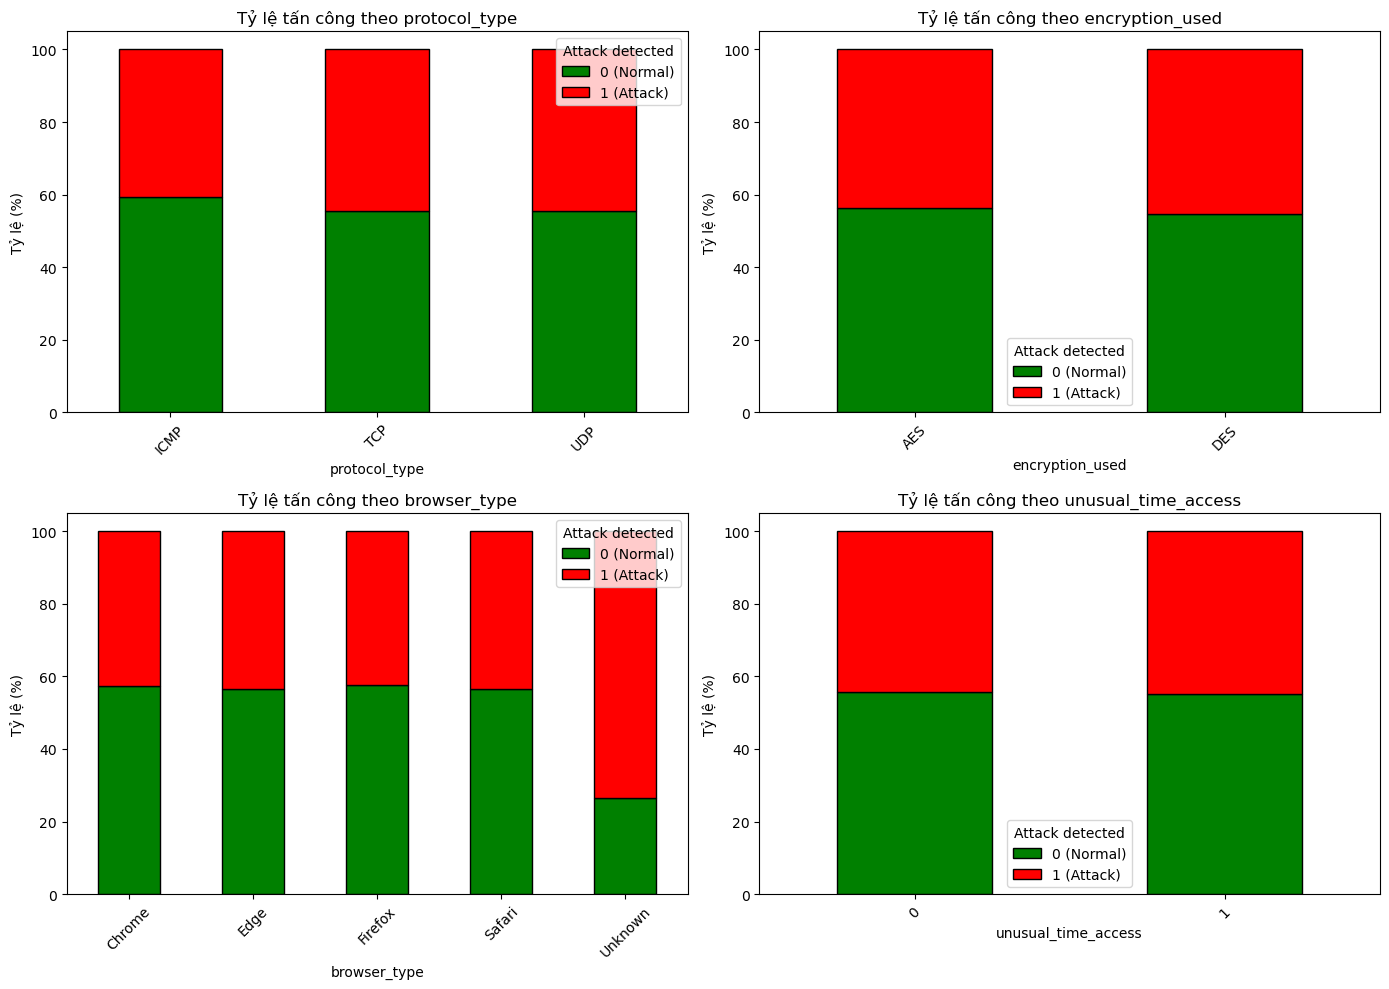


5.1. Kiểm định Chi-square giữa các biến phân loại và attack_detected:

--- protocol_type ---
  Chi-square: 2.1257
  p-value: 0.345470
 => Không có mối liên hệ có ý nghĩa thống kê

--- encryption_used ---
  Chi-square: 1.9520
  p-value: 0.162375
 => Không có mối liên hệ có ý nghĩa thống kê

--- browser_type ---
  Chi-square: 145.6944
  p-value: 0.000000
 => Có mối liên hệ có ý nghĩa thống kê (p < 0.05)

--- unusual_time_access ---
  Chi-square: 0.1521
  p-value: 0.696573
 => Không có mối liên hệ có ý nghĩa thống kê


In [6]:
print("5. PHÂN TÍCH CÁC BIẾN PHÂN LOẠI ")

categorical_cols = ['protocol_type', 'encryption_used', 'browser_type', 'unusual_time_access']

# 5.1. Biểu đồ tần suất phân bố theo từng lớp
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Tạo bảng chéo (crosstab) giữa biến phân loại và attack_detected
    ct = pd.crosstab(df[col], df['attack_detected'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['green', 'red'], edgecolor='black')
    axes[i].set_title(f'Tỷ lệ tấn công theo {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Tỷ lệ (%)')
    axes[i].legend(title='Attack detected', labels=['0 (Normal)', '1 (Attack)'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 5.2. Kiểm định Chi-square (thống kê mối quan hệ giữa biến phân loại và attack_detected)
from scipy.stats import chi2_contingency

print("\n5.1. Kiểm định Chi-square giữa các biến phân loại và attack_detected:")
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['attack_detected'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"\n--- {col} ---")
    print(f"  Chi-square: {chi2:.4f}")
    print(f"  p-value: {p:.6f}")
    if p < 0.05:
        print(f" => Có mối liên hệ có ý nghĩa thống kê (p < 0.05)")
    else:
        print(f" => Không có mối liên hệ có ý nghĩa thống kê")


### 6. PHÂN TÍCH HÀNH VI ĐĂNG NHẬP (LOGIN BEHAVIOR)


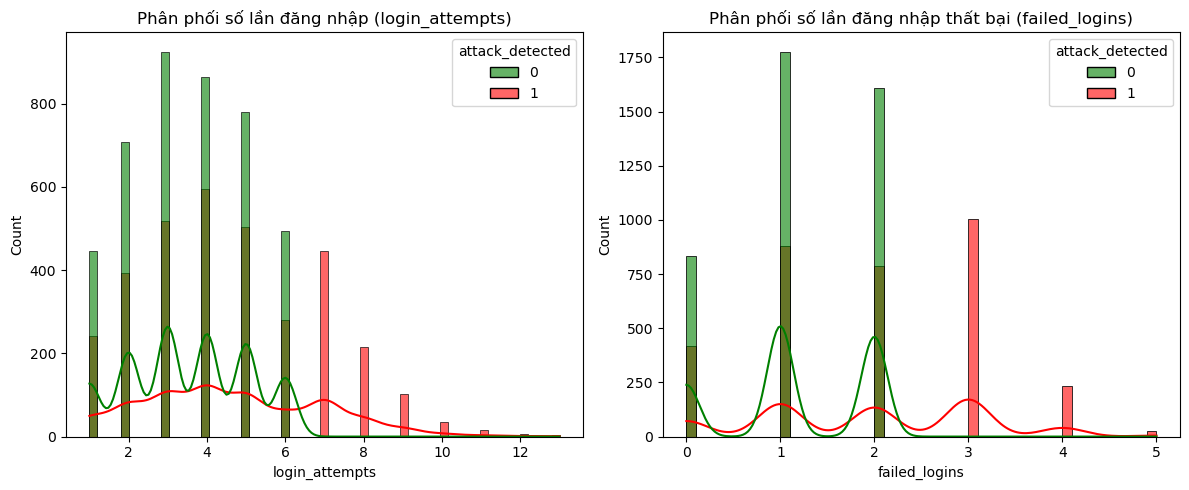


6.1. Thống kê tỷ lệ đăng nhập thất bại (failed_logins / login_attempts):
                  count      mean       std  min  25%       50%   75%  max
attack_detected                                                           
0                4217.0  0.441088  0.437350  0.0  0.2  0.333333  0.50  2.0
1                3354.0  0.626849  0.685675  0.0  0.2  0.428571  0.75  5.0


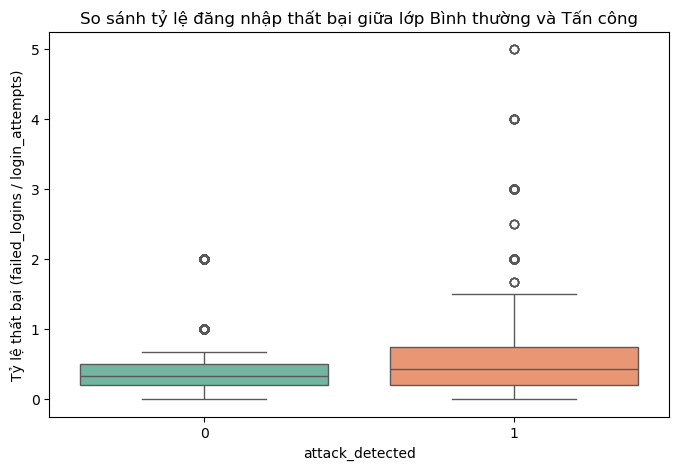

In [7]:
# 6.1. Phân phối số lần đăng nhập và số lần thất bại
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Số lần đăng nhập
sns.histplot(data=df, x='login_attempts', hue='attack_detected', 
             kde=True, alpha=0.6, palette=['green', 'red'], ax=axes[0])
axes[0].set_title('Phân phối số lần đăng nhập (login_attempts)')
axes[0].set_xlabel('login_attempts')

# Số lần đăng nhập thất bại
sns.histplot(data=df, x='failed_logins', hue='attack_detected', 
             kde=True, alpha=0.6, palette=['green', 'red'], ax=axes[1])
axes[1].set_title('Phân phối số lần đăng nhập thất bại (failed_logins)')
axes[1].set_xlabel('failed_logins')

plt.tight_layout()
plt.show()

# 6.2. Tạo đặc trưng mới: tỷ lệ thất bại trên tổng số lần đăng nhập
df['login_failure_ratio'] = df['failed_logins'] / df['login_attempts']
df['login_failure_ratio'] = df['login_failure_ratio'].fillna(0)  # Xử lý trường hợp login_attempts = 0

print("\n6.1. Thống kê tỷ lệ đăng nhập thất bại (failed_logins / login_attempts):")
print(df.groupby('attack_detected')['login_failure_ratio'].describe())

# 6.3. Biểu đồ boxplot so sánh tỷ lệ thất bại giữa 2 lớp
plt.figure(figsize=(8, 5))
sns.boxplot(x='attack_detected', y='login_failure_ratio', data=df, palette='Set2')
plt.title('So sánh tỷ lệ đăng nhập thất bại giữa lớp Bình thường và Tấn công')
plt.ylabel('Tỷ lệ thất bại (failed_logins / login_attempts)')
plt.show()



### 7. PHÂN TÍCH THEO THỜI GIAN (SESSION DURATION) VÀ IP REPUTATION

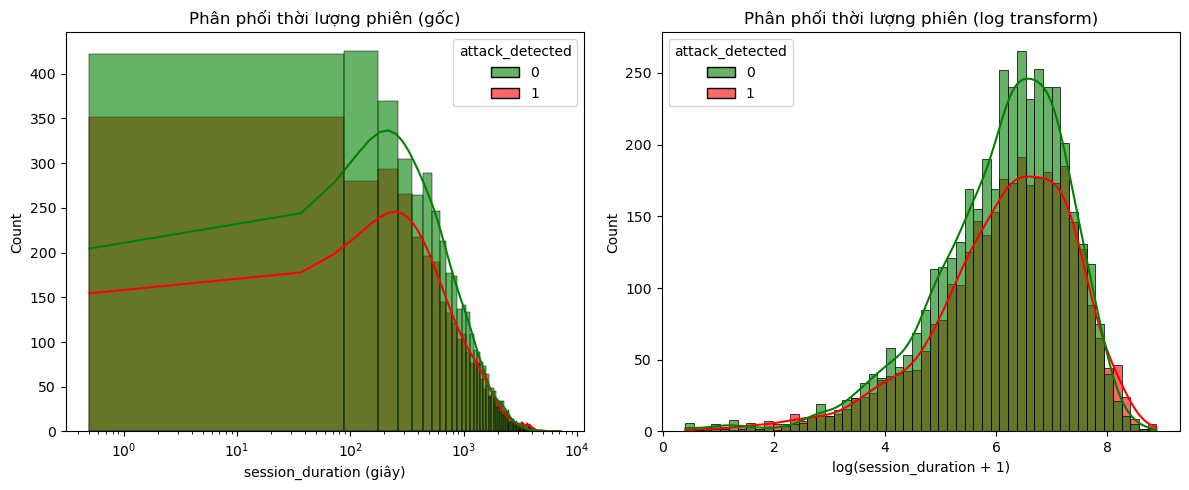

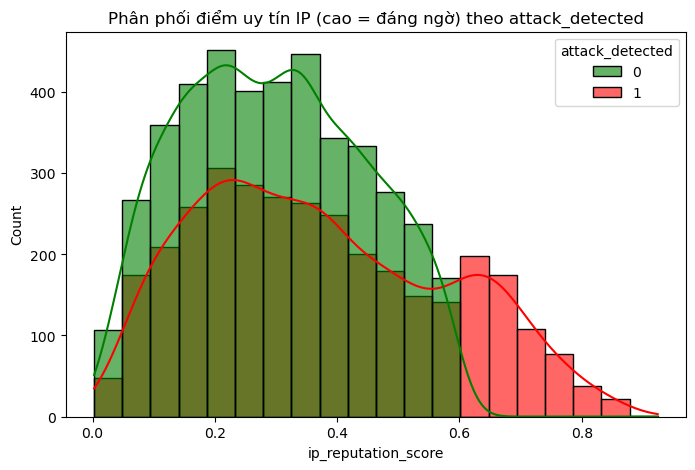

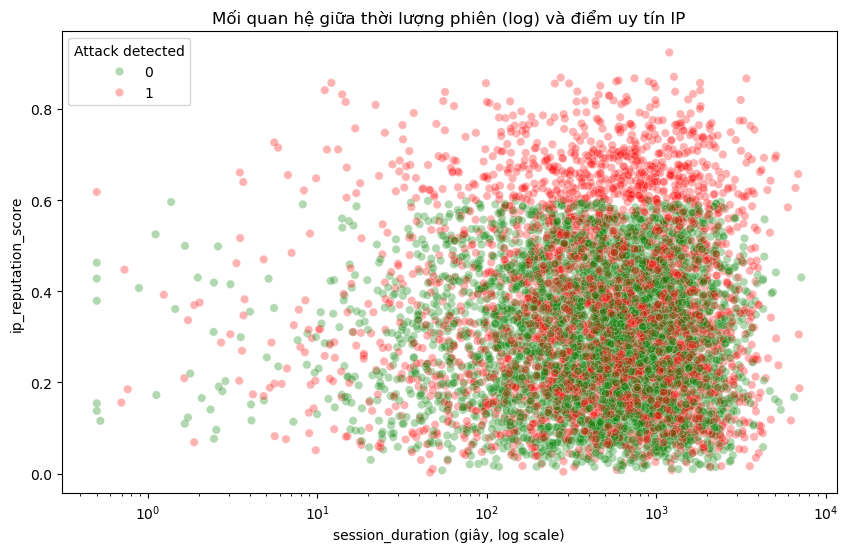

In [8]:
# 7.1. Phân phối thời lượng phiên (session_duration) - có thể log transform để nhìn rõ hơn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Thang đo gốc
sns.histplot(data=df, x='session_duration', hue='attack_detected', 
             kde=True, alpha=0.6, palette=['green', 'red'], ax=axes[0])
axes[0].set_title('Phân phối thời lượng phiên (gốc)')
axes[0].set_xlabel('session_duration (giây)')
axes[0].set_xscale('log')  # log scale để nhìn rõ

# Thang đo log
sns.histplot(data=df, x=np.log1p(df['session_duration']), hue='attack_detected', 
             kde=True, alpha=0.6, palette=['green', 'red'], ax=axes[1])
axes[1].set_title('Phân phối thời lượng phiên (log transform)')
axes[1].set_xlabel('log(session_duration + 1)')

plt.tight_layout()
plt.show()

# 7.2. Phân phối điểm uy tín IP (ip_reputation_score) - điểm cao là đáng ngờ
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='ip_reputation_score', hue='attack_detected', 
             kde=True, alpha=0.6, palette=['green', 'red'], bins=20)
plt.title('Phân phối điểm uy tín IP (cao = đáng ngờ) theo attack_detected')
plt.xlabel('ip_reputation_score')
plt.show()

# 7.3. Mối quan hệ giữa thời lượng phiên và điểm uy tín IP với attack_detected
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='session_duration', y='ip_reputation_score', 
                hue='attack_detected', alpha=0.3, palette=['green', 'red'])
plt.xscale('log')
plt.title('Mối quan hệ giữa thời lượng phiên (log) và điểm uy tín IP')
plt.xlabel('session_duration (giây, log scale)')
plt.ylabel('ip_reputation_score')
plt.legend(title='Attack detected')
plt.show()


### 8. PHÂN TÍCH ĐA BIẾN (MULTIVARIATE ANALYSIS)

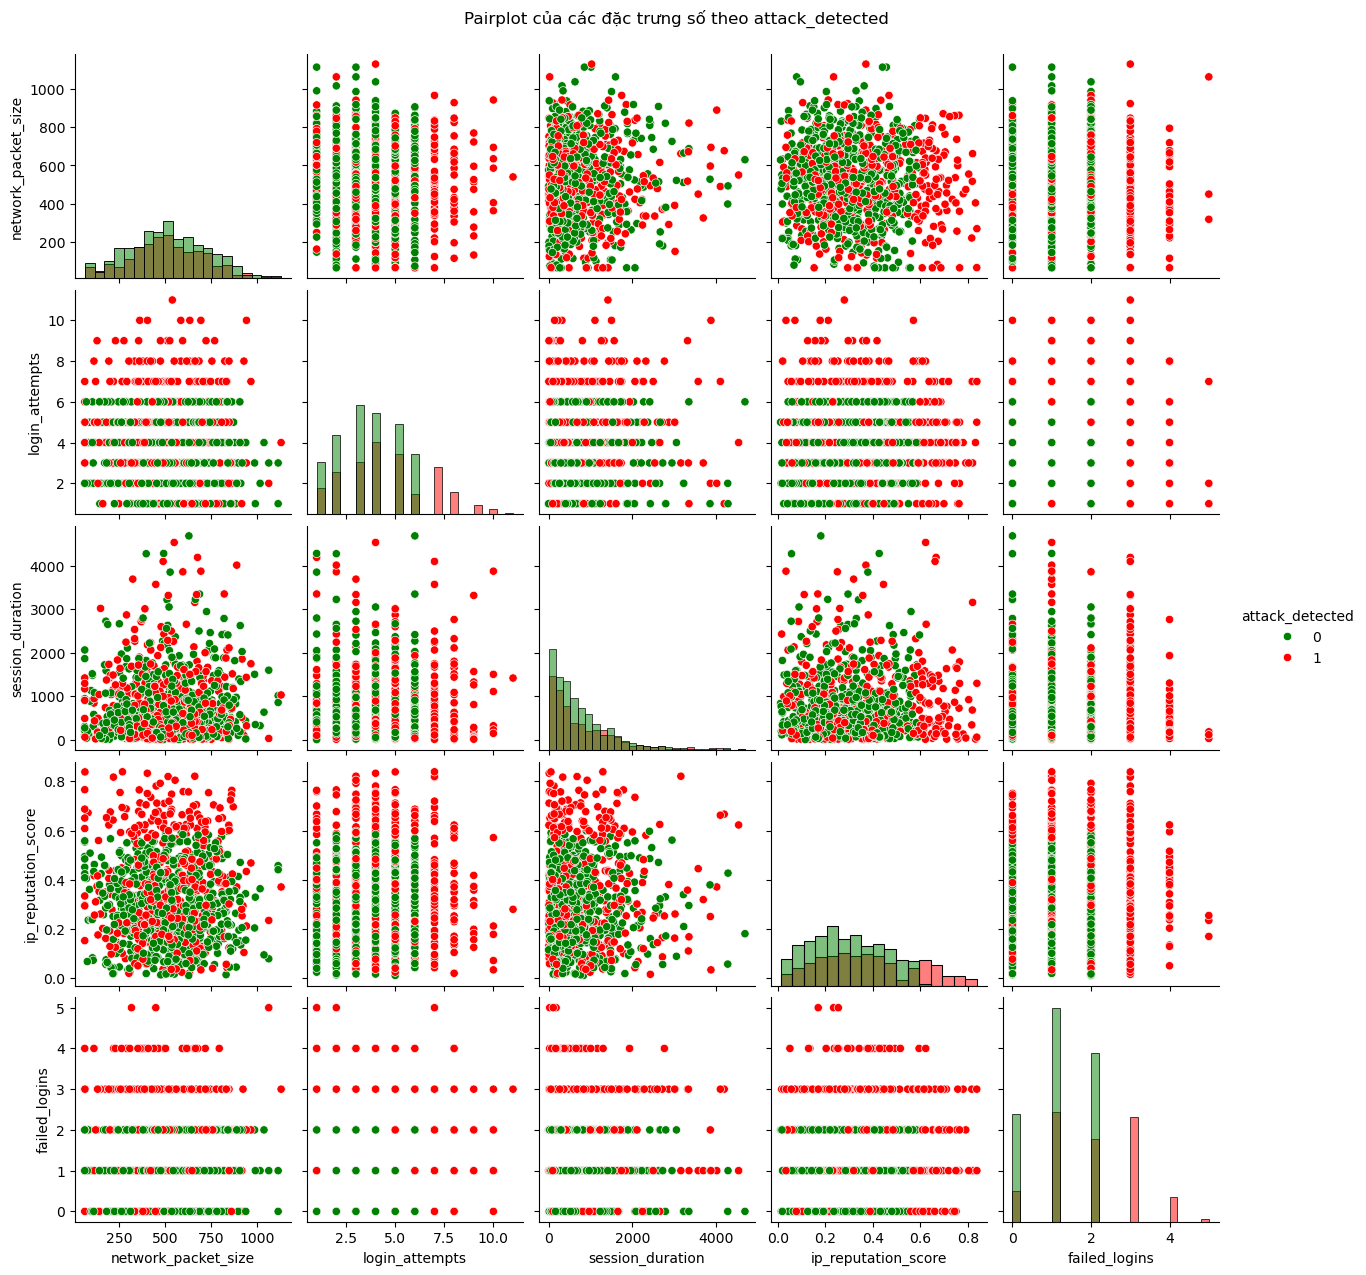

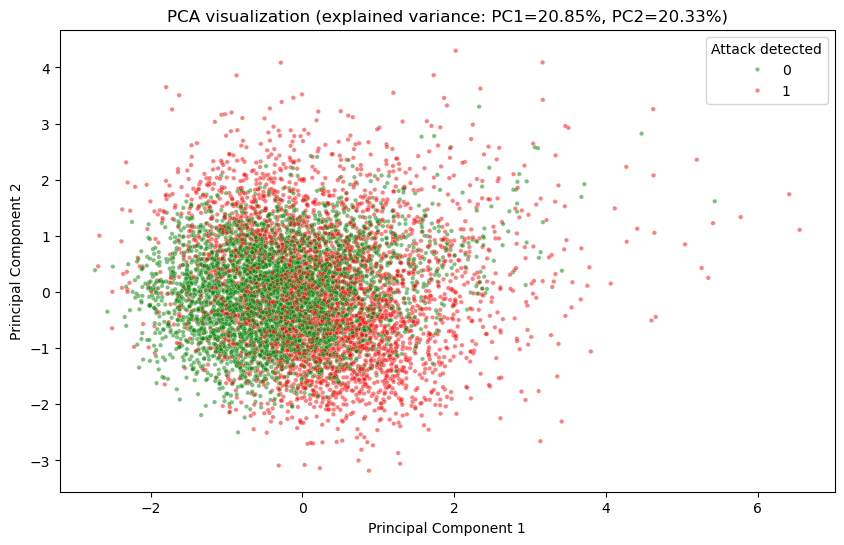


Phương sai giải thích bởi từng thành phần chính:
  PC1: 20.85%
  PC2: 20.33%
Tổng 2 thành phần: 41.18%


In [9]:
# 8.1. Pairplot cho một số cột quan trọng (chỉ lấy sample để tránh quá tải)
sample_df = df[numeric_cols + ['attack_detected']].sample(min(1000, len(df)))
sns.pairplot(sample_df, hue='attack_detected', palette=['green', 'red'], diag_kind='hist')
plt.suptitle('Pairplot của các đặc trưng số theo attack_detected', y=1.02)
plt.show()

# 8.2. Phân tích cụm (cluster analysis sơ bộ) bằng PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_pca['attack_detected'] = df['attack_detected'].values

# Vẽ biểu đồ PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='attack_detected', 
                alpha=0.5, palette=['green', 'red'], s=10)
plt.title(f'PCA visualization (explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Attack detected')
plt.show()

print("\nPhương sai giải thích bởi từng thành phần chính:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.2%}")
print(f"Tổng 2 thành phần: {pca.explained_variance_ratio_[:2].sum():.2%}")



### 9. TÓM TẮT CÁC PHÁT HIỆN CHÍNH (KEY FINDINGS)

In [10]:
print("=== 9. TÓM TẮT CÁC PHÁT HIỆN CHÍNH TỪ EDA ===")

print("""
1. CẤU TRÚC DỮ LIỆU:
   - Tổng số mẫu: {} hàng
   - Số cột: {} cột ({} số, {} phân loại)
   - Tỷ lệ tấn công: {:.2%}

2. ĐẶC TRƯNG SỐ:
   - Các đặc trưng có phân phối lệch (skewed), cần chuẩn hóa hoặc log transform
   - Phát hiện outlier ở nhiều đặc trưng, đặc biệt là session_duration và login_attempts

3. TƯƠNG QUAN:
   - Đặc trưng có tương quan mạnh nhất với attack_detected: 
     * failed_logins: {}
     * ip_reputation_score: {}
     * login_attempts: {}

4. BIẾN PHÂN LOẠI:
   - protocol_type: {}
   - encryption_used: {}
   - browser_type: {}
   - unusual_time_access: {}

5. HÀNH VI TẤN CÔNG ĐIỂN HÌNH:
   - Số lần đăng nhập thất bại cao
   - IP có reputation score cao (đáng ngờ)
   - Tỷ lệ đăng nhập thất bại trên tổng số lần cao
   - Xuất hiện nhiều hơn ở khung giờ bất thường

6. ĐỀ XUẤT XỬ LÝ:
   - Chuẩn hóa/chuẩn hóa các đặc trưng số
   - One-hot encoding cho biến phân loại
   - Xử lý mất cân bằng lớp (nếu cần)
   - Có thể tạo thêm đặc trưng tương tác (feature engineering)
""".format(
    df.shape[0], 
    df.shape[1], 
    len(numeric_cols), 
    len([c for c in df.columns if c not in numeric_cols + ['attack_detected', 'login_failure_ratio']]),
    df['attack_detected'].mean(),
    target_corr['failed_logins'] if 'failed_logins' in target_corr else 'N/A',
    target_corr['ip_reputation_score'] if 'ip_reputation_score' in target_corr else 'N/A',
    target_corr['login_attempts'] if 'login_attempts' in target_corr else 'N/A',
    "có phân bố lệch giữa các lớp" if len(df['protocol_type'].unique()) > 1 else "ít biến động",
    "có phân bố lệch giữa các lớp" if len(df['encryption_used'].unique()) > 1 else "ít biến động",
    "có phân bố lệch giữa các lớp" if len(df['browser_type'].unique()) > 1 else "ít biến động",
    "có ý nghĩa" if 'unusual_time_access' in df.columns else "không có trong dữ liệu"
))

=== 9. TÓM TẮT CÁC PHÁT HIỆN CHÍNH TỪ EDA ===

1. CẤU TRÚC DỮ LIỆU:
   - Tổng số mẫu: 7571 hàng
   - Số cột: 11 cột (5 số, 4 phân loại)
   - Tỷ lệ tấn công: 44.30%

2. ĐẶC TRƯNG SỐ:
   - Các đặc trưng có phân phối lệch (skewed), cần chuẩn hóa hoặc log transform
   - Phát hiện outlier ở nhiều đặc trưng, đặc biệt là session_duration và login_attempts

3. TƯƠNG QUAN:
   - Đặc trưng có tương quan mạnh nhất với attack_detected: 
     * failed_logins: 0.3675016480918343
     * ip_reputation_score: 0.21499415043626327
     * login_attempts: 0.27676981839837483

4. BIẾN PHÂN LOẠI:
   - protocol_type: có phân bố lệch giữa các lớp
   - encryption_used: có phân bố lệch giữa các lớp
   - browser_type: có phân bố lệch giữa các lớp
   - unusual_time_access: có ý nghĩa

5. HÀNH VI TẤN CÔNG ĐIỂN HÌNH:
   - Số lần đăng nhập thất bại cao
   - IP có reputation score cao (đáng ngờ)
   - Tỷ lệ đăng nhập thất bại trên tổng số lần cao
   - Xuất hiện nhiều hơn ở khung giờ bất thường

6. ĐỀ XUẤT XỬ LÝ:
   - Ch

### 10. LƯU KẾT QUẢ EDA

In [11]:
# Tạo thư mục lưu trữ kết quả
import os
eda_dir = "../data_processed/eda_results"
if not os.path.exists(eda_dir):
    os.makedirs(eda_dir)

# Lưu một số bảng thống kê quan trọng ra csv
# Thống kê tương quan với target
target_corr_df = pd.DataFrame(target_corr).reset_index()
target_corr_df.columns = ['feature', 'correlation_with_attack']
target_corr_df.to_csv(f"{eda_dir}/correlation_with_target.csv", index=False)

# Thống kê phân phối biến phân loại
for col in categorical_cols:
    if col in df.columns:
        freq_df = df[col].value_counts().reset_index()
        freq_df.columns = [col, 'count']
        freq_df['percentage'] = freq_df['count'] / len(df) * 100
        freq_df.to_csv(f"{eda_dir}/frequency_{col}.csv", index=False)

print(f"\nĐã lưu kết quả EDA vào thư mục: {eda_dir}")


Đã lưu kết quả EDA vào thư mục: ../data_processed/eda_results


## **KẾT THÚC PHẦN PHÂN TÍCH EDA**